# Final Project: Look at the data

In [28]:
from __future__ import print_function, division                     # Ensures Python3 printing & division standard
import gradio as gr                                                 #For creating interactive web interfaces
import IPython.display as ipd                                       #For displaying audio in Jupyter notebooks
import json
import librosa                                                      #For audio processing                    
import matplotlib.pyplot as plt                                     #For creating plots 
import numpy as np                                                  #For numerical operations
import optuna                                                       #For hyperparameter optimization
from optuna.pruners import MedianPruner
import os                                                           #For interacting with the operating system
import pandas as pd                                                 #For data manipulation and analysis 
import random
import seaborn as sns                                               #For statistical data visualization
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
import time
import torch
from torch import nn
import torchaudio.transforms as T
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import urllib.request


np.random.seed(42)
random.seed(42)

In [2]:
# Set the path to data
DATA_PATH = "/Users/livajuliesmidt/Desktop/ML/AppliedML2026/FinalProject_Liva/FP_data"

dev_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/dev.csv")
train_labels = dev_labels[dev_labels["split"] == "train"]
val_labels = dev_labels[dev_labels["split"] == "val"]
eval_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/eval.csv")

subset_percentage = 100
print(f"Using {subset_percentage}% of the training data equaling {int(len(train_labels) * subset_percentage / 100)} samples")
train_subset = train_labels.sample(n=int(len(train_labels) * subset_percentage / 100), random_state=42)

Using 100% of the training data equaling 36796 samples


In [3]:
#Function for extracting the spectrogram from an audio file, ensuring a fixed shape of (64, 216)
TARGET_SR = 22050                                       #Sample rate
DURATION = 5.0                                          #Seconds to keep (clip/pad to this length)
N_MELS = 64                                             #Number of mel bands to generate (bins in the spectrogram)
HOP_LENGTH = 512                                        #Number of samples between successive frames in the spectrogram
N_FRAMES = int(TARGET_SR * DURATION / HOP_LENGTH) + 1   #Number of frames in the spectrogram (~216 frames)

def extract_spectrogram(filepath):
    """Extracts a mel spectrogram from an audio file, ensuring a fixed shape of (64, 216).
    Inputs:
        filepath: Path to the audio file
    Outputs:
        mel_db: Mel spectrogram in decibels with shape (64, 216), or None if loading fails
    """
    try:
        audio, sr = librosa.load(filepath, sr=TARGET_SR, duration=DURATION, mono=True)
        
        # Pad if shorter than 5 seconds
        expected_samples = int(TARGET_SR * DURATION)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))
        
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        
        # Enforce fixed shape
        if mel_db.shape[1] < N_FRAMES:
            mel_db = np.pad(mel_db, ((0, 0), (0, N_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :N_FRAMES]
        
        return mel_db  # Shape: (64, 216)
    except:
        return None

In [4]:
print("Extracting 2D spectrograms from train split...")
spectrograms = []
valid_idx = []  

for i, row in tqdm(train_subset.iterrows(), total=len(train_subset)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_train = np.array(spectrograms)              # (n_clips, 64, 216)
X_train = X_train[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
train_true = train_subset.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_train shape: {X_train.shape}")

print(f"Number of successfully processed samples: {len(train_true)}")
print(f"Number of unsuccessful samples: {len(train_subset) - len(train_true)}")

Extracting 2D spectrograms from train split...


100%|██████████| 36796/36796 [03:56<00:00, 155.36it/s]


X_train shape: (36796, 1, 64, 216)
Number of successfully processed samples: 36796
Number of unsuccessful samples: 0


In [5]:
print("Extracting 2D spectrograms from validation split...")
spectrograms = []
valid_idx = []

for i, row in tqdm(val_labels.iterrows(), total=len(val_labels)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_val = np.array(spectrograms)              # (n_clips, 64, 216)
X_val = X_val[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
val_true = val_labels.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_val shape: {X_val.shape}")

print(f"Number of successfully processed samples: {len(val_true)}")
print(f"Number of unsuccessful samples: {len(val_labels) - len(val_true)}")


Extracting 2D spectrograms from validation split...


100%|██████████| 4170/4170 [00:29<00:00, 141.85it/s]


X_val shape: (4170, 1, 64, 216)
Number of successfully processed samples: 4170
Number of unsuccessful samples: 0


In [6]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std  # use train stats, not val stats!

In [7]:
url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"
urllib.request.urlretrieve(url, "ontology.json")

with open("ontology.json") as f:
    ontology = json.load(f)

ontology_by_id = {entry["id"]: entry for entry in ontology}     # Build a lookup: mid → full entry

child_to_parent = {}                                            # Build a reverse lookup: child_mid → parent_mid
for entry in ontology:
    for child_id in entry["child_ids"]:
        child_to_parent[child_id] = entry["id"]


top_level = {                                                   # The 6 top-level family MIDs (updated to match the discovered ontology structure)
    "/m/0dgw9r": "Human sounds",
    "/m/0jbk":   "Animal",
    "/m/04rlf":  "Music",
    "/m/059j3w": "Natural sounds",
    "/t/dd00041": "Sounds of things",
    "/t/dd00098": "Source-ambiguous sounds",
}

def get_top_level_family(mid):
    current = mid
    while current not in top_level:
        parent = child_to_parent.get(current)
        if parent is None:
            return "Unknown"                                    # shouldn't happen for FSD50K classes
        current = parent
    return top_level[current]

train_true["family"] = train_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
val_true["family"] = val_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))


In [8]:
le = LabelEncoder()
y_train = le.fit_transform(train_true["family"])

print(train_true["family"].value_counts())
print(f"Classes: {len(le.classes_)}, y_train shape: {y_train.shape}")


family
Sounds of things           11669
Music                      11476
Human sounds                6540
Animal                      2684
Source-ambiguous sounds     2567
Natural sounds              1860
Name: count, dtype: int64
Classes: 6, y_train shape: (36796,)


In [ ]:
# --- Create these ONCE, before the objective function ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)                                                          #Convert training data to PyTorch tensor of type float32
y_train_t = torch.tensor(y_train, dtype=torch.long)                                                             #Convert training labels to PyTorch tensor of type long (integer class indices) 
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t  = torch.tensor(le.transform(val_true["family"]), dtype=torch.long)

n_classes = len(le.classes_)                                                                                    #Number of unique classes in the dataset
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")                                    #Use Apple Silicon GPU if available, otherwise CPU
X_val_t_device = X_val_t.to(device)

class_counts = torch.tensor([np.sum(y_train == i) for i in range(n_classes)],dtype=torch.float32)               # Compute class weights inversely proportional to frequency
class_weights = 1.0 / class_counts
class_weights_normalized = class_weights / class_weights.sum()             

number_of_optuna_epochs = 10                                                 

def objective(trial):
    # --- Hyperparameters to tune ---
    lr           = trial.suggest_float("lr", 1e-5, 1e-2, log=True)              #Learning rate
    dropout      = trial.suggest_float("dropout", 0.2, 0.7)                     #Dropout rate for regularization
    batch_size   = trial.suggest_categorical("batch_size", [32, 64, 128])       #Batch size for training
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)    #L2 regularization strength

    # --- Build model with tunable dropout ---
    class AudioCNN_Optuna(nn.Module):
        def __init__(self, n_classes, dropout):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.LazyLinear(256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, n_classes)
            )
        def forward(self, x):
            return self.classifier(self.conv(x))
    
    model = AudioCNN_Optuna(n_classes, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, num_workers=0)

    criterion = nn.CrossEntropyLoss(weight=class_weights_normalized.to(device))

    # --- Training loop ---
    for epoch in range(number_of_optuna_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Validation accuracy for pruning
        model.eval()
        all_preds = []
        with torch.no_grad():
            for i in range(0, len(X_val_t_device), 256):  # Process in batches to avoid memory issues
                xb = X_val_t_device[i:i+256]
                preds = model(xb).argmax(1).cpu()
                all_preds.append(preds)

        all_preds = torch.cat(all_preds)
        val_acc = (all_preds == y_val_t).float().mean().item()

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return val_acc

# --- Run the study ---
start_time = time.time()
study = optuna.create_study(
    study_name="audioCNN_FSD50k_TPESampler",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)

n_trials = 30
study.optimize(objective, n_trials=n_trials, timeout=None)  
end_time = time.time()
total_time = end_time - start_time
from datetime import datetime

# --- Results ---
print(f"\nBest trial: {study.best_trial.number}")
print(f"Best val accuracy: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

with open("Optuna_TPE_log.txt", "a") as f: #Save loss and acc in a new line in txt file
    f.write(f"Best trial: {study.best_trial.number}/{n_trials}, Best val accuracy: {study.best_trial.value:.4f}, \n    (HP's) ")
    for k, v in study.best_trial.params.items():
        f.write(f"{k}: {v}, ")
    f.write(f"\n    Epochs: {number_of_optuna_epochs}, Classes: {n_classes}, Number of samples: {y_train.shape[0]}, Runtime: {total_time/60:.1f} min, Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")


[I 2026-06-02 23:12:18,660] A new study created in memory with name: audioCNN_FSD50k_TPESampler
[I 2026-06-02 23:32:36,836] Trial 0 finished with value: 0.567625880241394 and parameters: {'lr': 0.0001329291894316216, 'dropout': 0.675357153204958, 'batch_size': 32, 'weight_decay': 2.9375384576328313e-06}. Best is trial 0 with value: 0.567625880241394.
[I 2026-06-02 23:51:26,059] Trial 1 finished with value: 0.543405294418335 and parameters: {'lr': 1.493656855461762e-05, 'dropout': 0.6330880728874676, 'batch_size': 64, 'weight_decay': 0.0008123245085588687}. Best is trial 0 with value: 0.567625880241394.
[I 2026-06-03 00:12:18,247] Trial 2 finished with value: 0.5872901678085327 and parameters: {'lr': 0.00314288089084011, 'dropout': 0.3061695553391381, 'batch_size': 128, 'weight_decay': 3.752055855124284e-05}. Best is trial 2 with value: 0.5872901678085327.
[I 2026-06-03 00:32:42,784] Trial 3 finished with value: 0.6304556131362915 and parameters: {'lr': 0.00019762189340280086, 'dropout'


Best trial: 27
Best val accuracy: 0.6338
Best hyperparameters:
  lr: 0.00013821277259636842
  dropout: 0.26143438117947015
  batch_size: 32
  weight_decay: 5.869651947652391e-05


In [ ]:
print("Class weights normalized:", class_weights_normalized)
print("min weight: {:.4f}, max weight: {:.4f}".format(class_weights_normalized.min().item(), class_weights_normalized.max().item()))

Class weights normalized: tensor([0.2292, 0.0941, 0.0536, 0.3307, 0.0527, 0.2397])
min weight: 0.0527, max weight: 0.3307
sum of weights: 1.0000


Since you're running in Jupyter though, the easiest approach is just opening a separate Terminal tab and running caffeinate there while your notebook runs. Kill it with Ctrl+C when you're done

Best trial: 27
Best val accuracy: 0.6338
Best hyperparameters:
  lr: 0.00013821277259636842
  dropout: 0.26143438117947015
  batch_size: 32
  weight_decay: 5.869651947652391e-05

In [35]:
def augment_spec(spec):
    """Applies time and frequency masking to a spectrogram for data augmentation.
    Inputs:
        spec: Input spectrogram tensor of shape (1, 64, 216)
    Outputs:
        Augmented spectrogram tensor of the same shape
    """
    time_mask = T.TimeMasking(time_mask_param=40)
    freq_mask = T.FrequencyMasking(freq_mask_param=8)
    spec = time_mask(spec)
    spec = freq_mask(spec)
    return spec

In [36]:
number_of_optuna_epochs = 10       

# --- Hyperparameters ---
lr           = study.best_trial.params["lr"]
dropout      = study.best_trial.params["dropout"]
batch_size   = study.best_trial.params["batch_size"]
weight_decay = study.best_trial.params["weight_decay"]

# --- Build model with tunable dropout ---
class AudioCNN_Optuna(nn.Module):
    def __init__(self, n_classes, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.conv(x))

model = AudioCNN_Optuna(n_classes, dropout).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size, shuffle=True, num_workers=0)

criterion = nn.CrossEntropyLoss(weight=class_weights_normalized.to(device))

# --- Training loop ---
for epoch in range(number_of_optuna_epochs):
    model.train()
    all_train_preds = []
    all_train_labels = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = augment_spec(xb)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        all_train_preds.append(out.argmax(1).detach().cpu()) 
        all_train_labels.append(yb.cpu())             

    train_acc = (torch.cat(all_train_preds) == torch.cat(all_train_labels)).float().mean().item()


    # Validation accuracy
    model.eval()
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(X_val_t_device), 256):  # Process in batches to avoid memory issues
            xb = X_val_t_device[i:i+256]
            preds = model(xb).argmax(1).cpu()
            all_preds.append(preds)

    all_preds = torch.cat(all_preds)
    val_acc = (all_preds == y_val_t).float().mean().item()
    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")


Epoch 01 | Train Acc: 0.432 | Val Acc: 0.371
Epoch 02 | Train Acc: 0.506 | Val Acc: 0.446
Epoch 03 | Train Acc: 0.529 | Val Acc: 0.428
Epoch 04 | Train Acc: 0.555 | Val Acc: 0.392
Epoch 05 | Train Acc: 0.569 | Val Acc: 0.506
Epoch 06 | Train Acc: 0.585 | Val Acc: 0.554
Epoch 07 | Train Acc: 0.596 | Val Acc: 0.455
Epoch 08 | Train Acc: 0.615 | Val Acc: 0.525
Epoch 09 | Train Acc: 0.621 | Val Acc: 0.419
Epoch 10 | Train Acc: 0.631 | Val Acc: 0.554


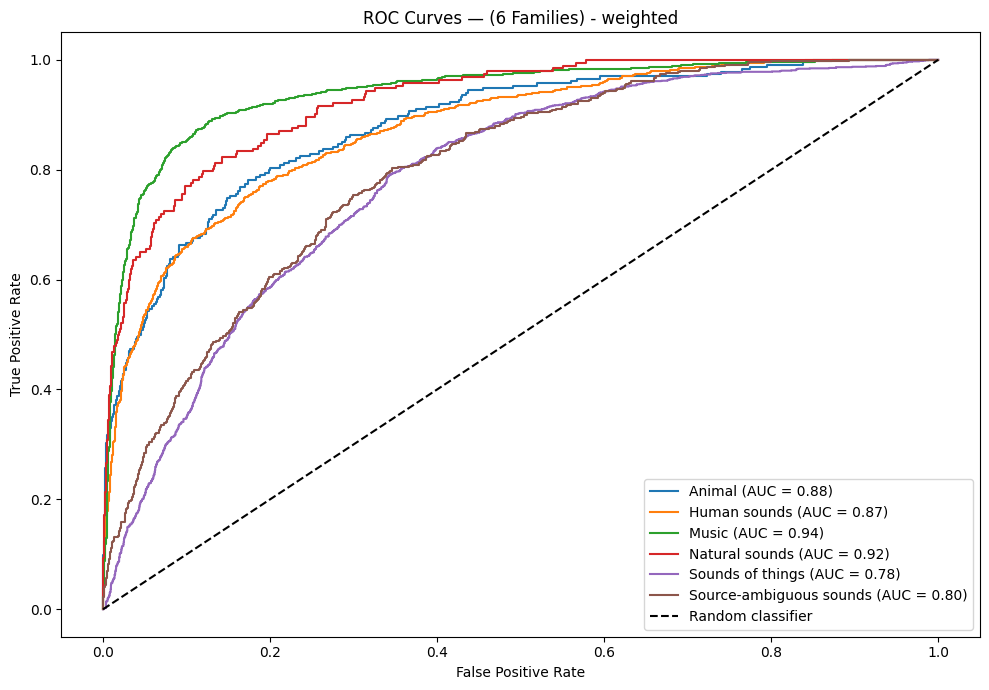

Mean Average Precision (mAP): 0.5847


In [37]:
# --- Get predicted probabilities for all val samples ---
model.eval()
all_probs = []
with torch.no_grad():
    for i in range(0, len(X_val_t_device), 256):
        xb = X_val_t_device[i:i+256]
        probs = torch.softmax(model(xb), dim=1).cpu().numpy()
        all_probs.append(probs)

all_probs = np.vstack(all_probs)  # (n_val_samples, 6)

# --- Binarize true labels for one-vs-rest ---
y_val_np = y_val_t.numpy()
y_bin = label_binarize(y_val_np, classes=list(range(n_classes)))  # (n_val_samples, 6)

# --- Plot ROC curves ---
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — (6 Families) - weighted")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#calculate the Mean accurate prediction (mAP) for the validation set
from sklearn.metrics import average_precision_score
mAP = average_precision_score(y_bin, all_probs, average="macro")
print(f"Mean Average Precision (mAP): {mAP:.4f}")
